In [144]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.iv import IV2SLS
import matplotlib.pyplot as plt
import seaborn as sns

df_final = pd.read_csv("/Users/mari/Desktop/hse/метрика 2/дз2/final_merged_data.csv")


### Знакомство с данными 

Дескриптивная статистика:
       Electoral_Democracy_Index_2023  GDP_per_capita_2023  \
count                       97.000000            98.000000   
mean                         0.550515         24394.530282   
std                          0.276407         28312.302116   
min                          0.073000           193.007146   
25%                          0.285000          1623.922485   
50%                          0.576000         13803.535121   
75%                          0.837000         35855.195183   
max                          0.916000        128678.189943   

       Investments_percent_GDP_2023  Urbanization_percent_2023  \
count                     91.000000                 100.000000   
mean                      23.088556                  62.964320   
std                        6.709845                  23.030509   
min                        2.172798                  14.784000   
25%                       19.462811                  44.442500   
50%                

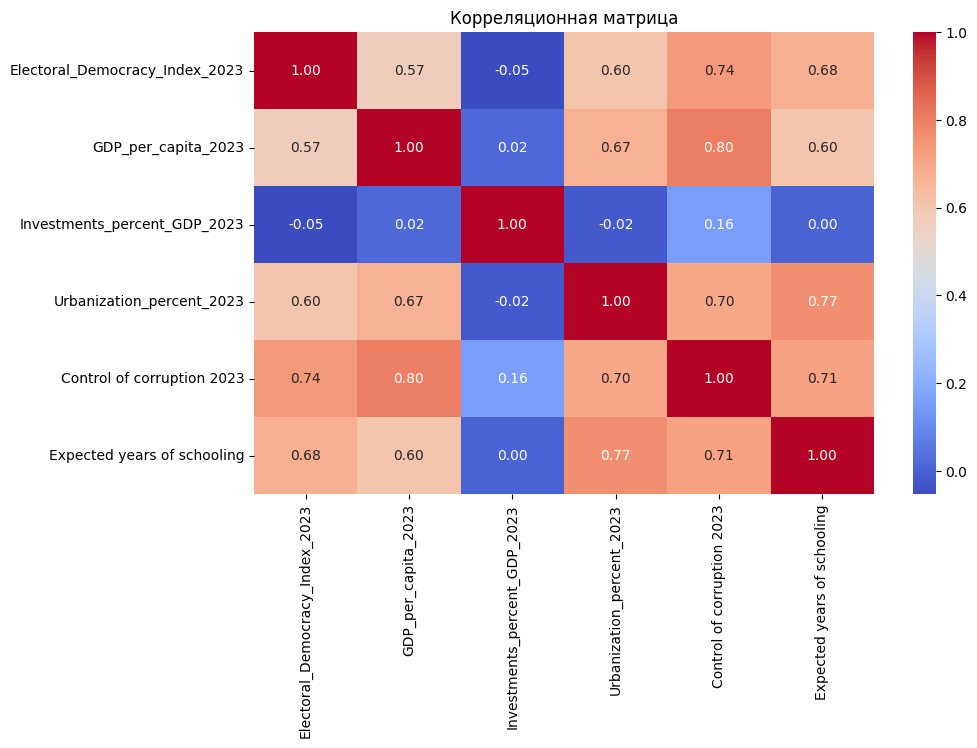

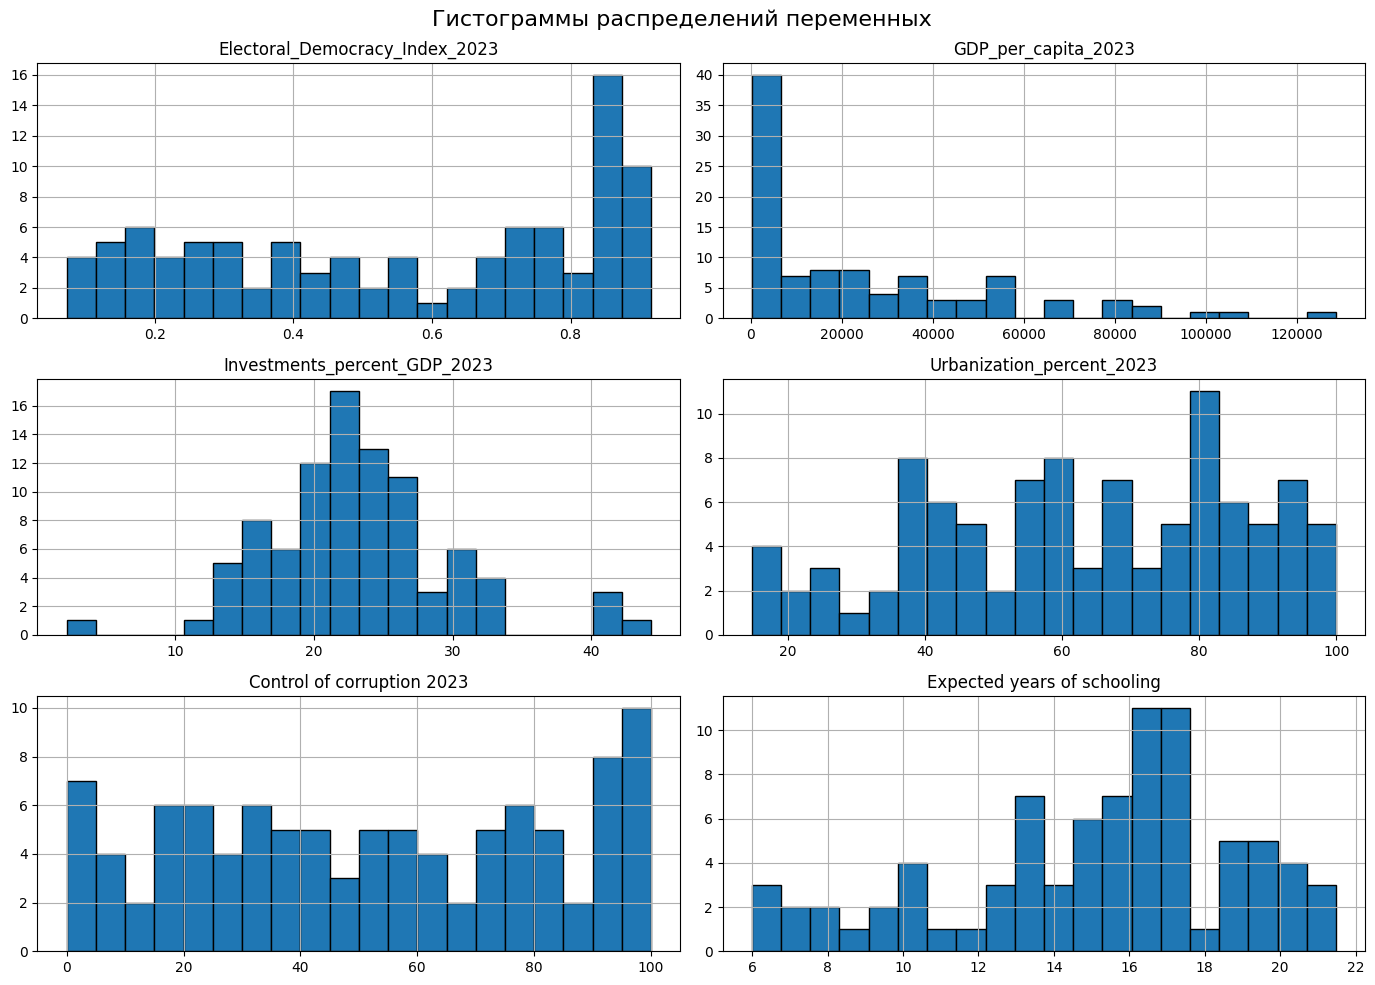

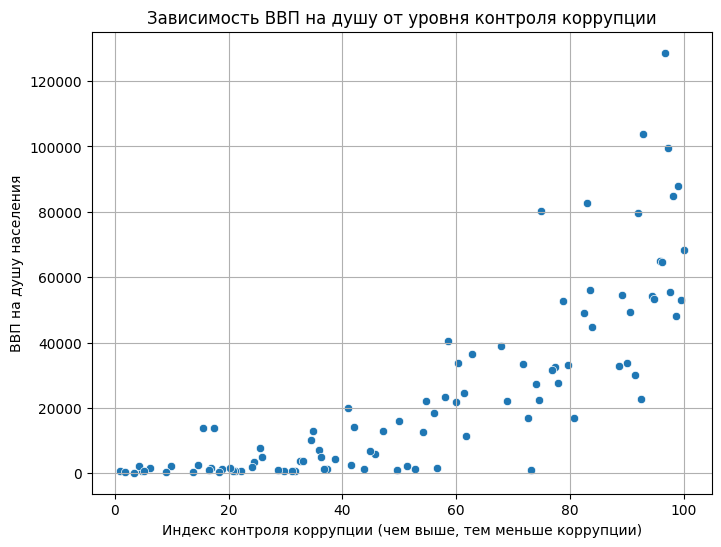

In [145]:
desc_stats = df_final.describe()
print("Дескриптивная статистика:")
print(desc_stats)

plt.figure(figsize=(10, 6))
sns.heatmap(df_final.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()

df_final.hist(bins=20, figsize=(14, 10), edgecolor='black')
plt.suptitle("Гистограммы распределений переменных", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_final,
    x='Control of corruption 2023',
    y='GDP_per_capita_2023'
)
plt.title("Зависимость ВВП на душу от уровня контроля коррупции")
plt.xlabel("Индекс контроля коррупции (чем выше, тем меньше коррупции)")
plt.ylabel("ВВП на душу населения")
plt.grid(True)
plt.show()

df_final['log_gdp'] = df_final['GDP_per_capita_2023'].apply(lambda x: np.log(x) if x > 0 else None)



In [146]:
df=df_final

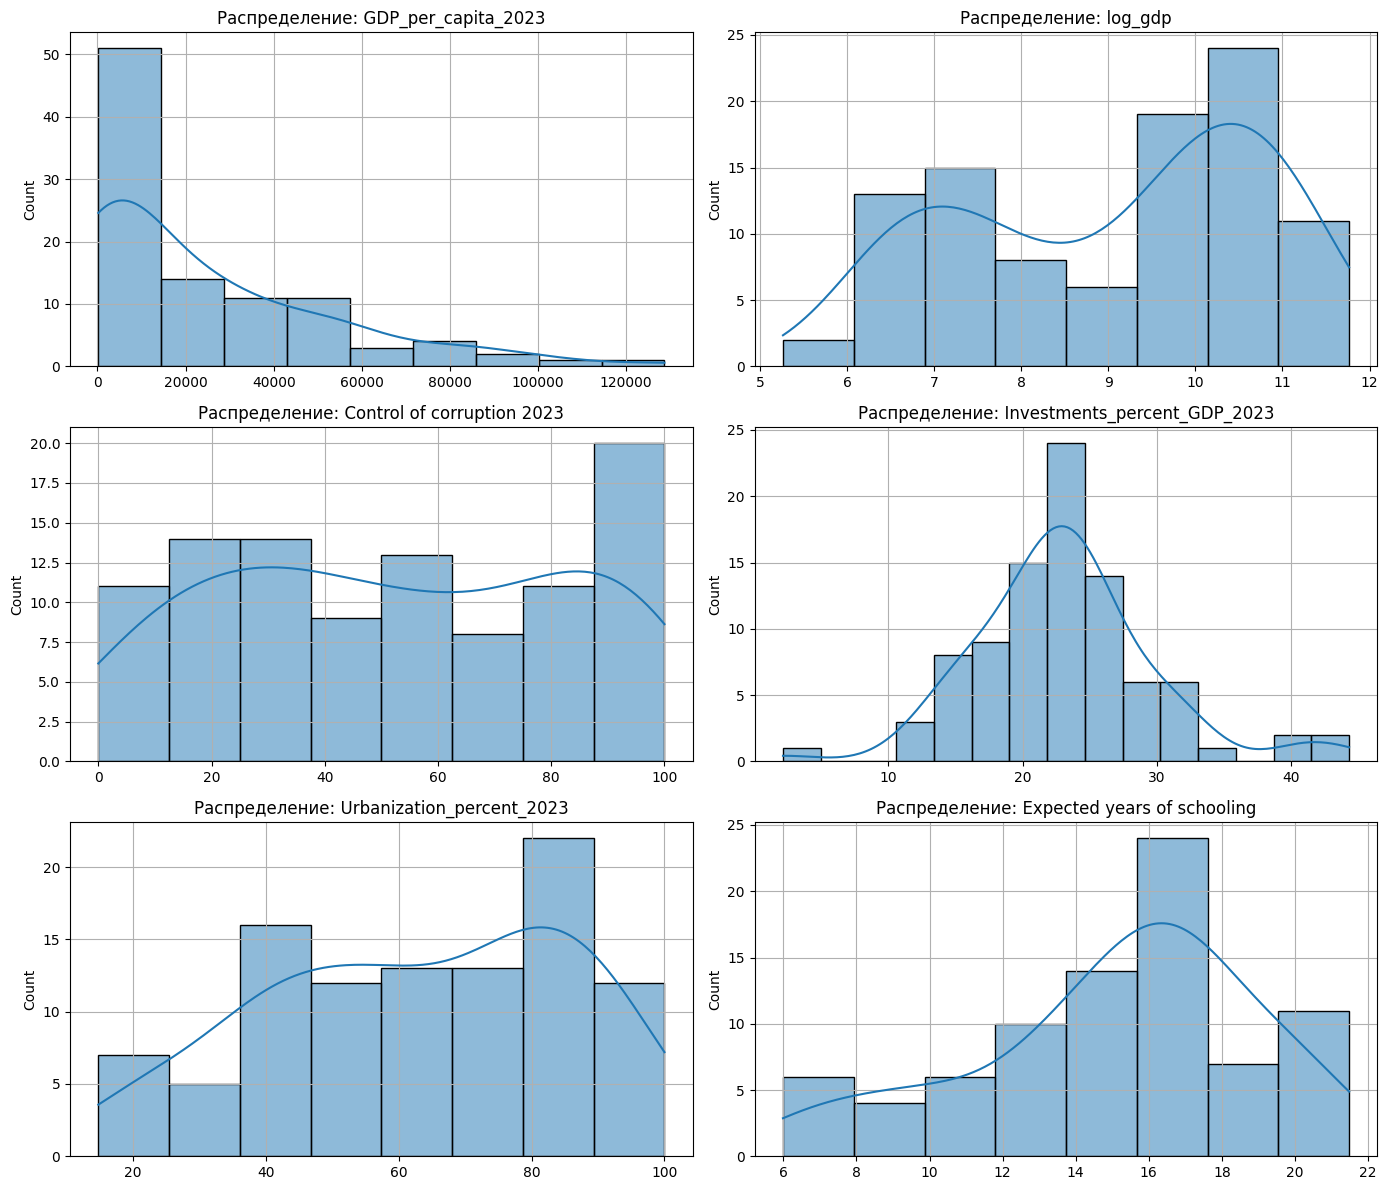

In [147]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

cols = [
    'GDP_per_capita_2023',
    'log_gdp',
    'Control of corruption 2023',
    'Investments_percent_GDP_2023',
    'Urbanization_percent_2023',
    'Expected years of schooling'
]

for i, col in enumerate(cols):
    sns.histplot(df_final[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение: {col}')
    axes[i].set_xlabel('')
    axes[i].grid(True)

plt.tight_layout()
plt.show()


### Смотрим на пропущенные значения

In [148]:
missing_mask = df.isnull().any(axis=1)
missing_countries = df.loc[missing_mask, 'Country'].tolist()

print("Страны с пропущенными значениями:")
print(missing_countries)

print("\nСредние значения для стран с пропущенными переменными:")
print(df[missing_mask][['GDP_per_capita_2023', 'Control of corruption 2023']].mean())

print("\nСредние значения для полной выборки:")
print(df[['GDP_per_capita_2023', 'Control of corruption 2023']].mean())


Страны с пропущенными значениями:
['Qatar', 'Kuwait', 'Brunei', 'Czech Republic', 'Trinidad and Tobago', 'China', 'Nigeria', 'Kenya', 'Ethiopia', 'Uganda', 'Zambia', 'Zimbabwe', 'Central African Republic', 'South Sudan', 'Somalia', 'Haiti', 'Yemen', 'Syria', 'Liberia', 'Sierra Leone', 'Malawi', 'Congo (Democratic Republic)', 'Guinea']

Средние значения для стран с пропущенными переменными:
GDP_per_capita_2023           10857.012153
Control of corruption 2023       28.835111
dtype: float64

Средние значения для полной выборки:
GDP_per_capita_2023           24394.530282
Control of corruption 2023       52.349057
dtype: float64


### удаляем пропущенные переменные(подробности в работе), преобразовываем переменные (логарифмируем ВВП)

In [149]:
df.columns = df.columns.str.strip().str.replace(" ", "_")



clean_df = df.dropna(subset=[
    "GDP_per_capita_2023",
    "Control_of_corruption_2023",
    "Electoral_Democracy_Index_2023",
    "Expected_years_of_schooling",
    "Investments_percent_GDP_2023",
    "Urbanization_percent_2023"
]).copy()

clean_df["log_GDP"] = np.log(clean_df["GDP_per_capita_2023"])


### оценка моделей

#### OLS модель 

In [150]:
X_ols = clean_df[[
    "Control_of_corruption_2023",
    "Expected_years_of_schooling",
    "Investments_percent_GDP_2023",
    "Urbanization_percent_2023"
]]
X_ols = sm.add_constant(X_ols)
y_ols = clean_df["log_GDP"]

ols_model = sm.OLS(y_ols, X_ols).fit(cov_type='HC0')
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                log_GDP   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     120.2
Date:                Sun, 18 May 2025   Prob (F-statistic):           4.36e-31
Time:                        16:48:25   Log-Likelihood:                -67.638
No. Observations:                  77   AIC:                             145.3
Df Residuals:                      72   BIC:                             157.0
Df Model:                           4                                         
Covariance Type:                  HC0                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [151]:
from stargazer.stargazer import Stargazer
from IPython.display import HTML

stargazer = Stargazer([ols_model])
stargazer.title('Результаты OLS-регрессии')
html_content = stargazer.render_html()

with open('ols_results.html', 'w', encoding='utf-8') as f:
    f.write(html_content)


#### IV модель (2SLS)

In [152]:

iv_model = IV2SLS.from_formula(
    "log_GDP ~ 1 + Expected_years_of_schooling + Investments_percent_GDP_2023 + Urbanization_percent_2023 "
    "[Control_of_corruption_2023 ~ Electoral_Democracy_Index_2023]",
    data=clean_df
).fit(cov_type='robust')
print(iv_model.summary)


                          IV-2SLS Estimation Summary                          
Dep. Variable:                log_GDP   R-squared:                      0.8714
Estimator:                    IV-2SLS   Adj. R-squared:                 0.8642
No. Observations:                  77   F-statistic:                    450.79
Date:                Sun, May 18 2025   P-value (F-stat)                0.0000
Time:                        16:48:25   Distribution:                  chi2(4)
Cov. Estimator:                robust                                         
                                                                              
                                      Parameter Estimates                                       
                              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------
Intercept                        4.4854     0.4822     9.3025     0.0000     

In [153]:
from stargazer.stargazer import Stargazer
from IPython.display import HTML

stargazer = Stargazer([iv_model])
stargazer.title('Результаты IV-2SLS-регрессии')
html_content = stargazer.render_html()

with open('2sls_results.html', 'w', encoding='utf-8') as f:
    f.write(html_content)


### тесты 

In [154]:
X_fs = clean_df[[
    "Electoral_Democracy_Index_2023",
    "Expected_years_of_schooling",
    "Investments_percent_GDP_2023",
    "Urbanization_percent_2023"
]]
X_fs = sm.add_constant(X_fs)
y_fs = clean_df["Control_of_corruption_2023"]

fs_model = sm.OLS(y_fs, X_fs).fit(cov_type='HC0')
print(fs_model.summary())

print(f"F-статистика первой стадии: {fs_model.fvalue:.2f}")
print(f"p-value: {fs_model.f_pvalue:.4f}")


                                OLS Regression Results                                
Dep. Variable:     Control_of_corruption_2023   R-squared:                       0.670
Model:                                    OLS   Adj. R-squared:                  0.651
Method:                         Least Squares   F-statistic:                     61.90
Date:                        Sun, 18 May 2025   Prob (F-statistic):           1.44e-22
Time:                                16:48:25   Log-Likelihood:                -325.43
No. Observations:                          77   AIC:                             660.9
Df Residuals:                              72   BIC:                             672.6
Df Model:                                   4                                         
Covariance Type:                          HC0                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

In [155]:
clean_df["resid_fs"] = fs_model.resid

X_hausman = clean_df[[
    "Control_of_corruption_2023",
    "Expected_years_of_schooling",
    "Investments_percent_GDP_2023",
    "Urbanization_percent_2023",
    "resid_fs"
]]
X_hausman = sm.add_constant(X_hausman)
y_hausman = clean_df["log_GDP"]

hausman_model = sm.OLS(y_hausman, X_hausman).fit(cov_type='HC0')
print(hausman_model.summary())

print(f"\nP-value теста Хаусмана (остатки первой стадии): {hausman_model.pvalues['resid_fs']:.4f}")


                            OLS Regression Results                            
Dep. Variable:                log_GDP   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     98.37
Date:                Sun, 18 May 2025   Prob (F-statistic):           1.66e-30
Time:                        16:48:25   Log-Likelihood:                -67.638
No. Observations:                  77   AIC:                             147.3
Df Residuals:                      71   BIC:                             161.3
Df Model:                           5                                         
Covariance Type:                  HC0                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [156]:
clean_df

,Country,Electoral_Democracy_Index_2023,GDP_per_capita_2023,Investments_percent_GDP_2023,Urbanization_percent_2023,Control_of_corruption_2023,Expected_years_of_schooling,log_gdp,log_GDP,resid_fs
0,Luxembourg,0.874,128678.189943,17.950223,92.078,96.698112,14.503,11.765070,11.765070,24.260874
1,Ireland,0.895,103887.800388,26.332252,64.466,92.924530,19.569,11.551067,11.551067,7.068675
2,Switzerland,0.887,99564.710026,24.576495,74.202,97.169815,16.799,11.508563,11.508563,17.249696
3,Norway,0.884,87925.094419,25.876017,83.995,99.056602,19.719,11.384241,11.384241,10.599315
4,Singapore,0.403,84734.255921,21.019016,100.000,98.113205,16.890,11.347275,11.347275,41.534068
...,...,...,...,...,...,...,...,...,...,...
93,Rwanda,0.213,1010.268929,23.285902,17.892,73.113205,12.547,6.917972,6.917972,47.259415
95,Madagascar,0.479,506.159369,21.593686,40.556,18.396227,9.465,6.226852,6.226852,-17.247671
96,Togo,0.394,985.697513,22.954480,44.490,28.773584,11.493,6.893350,6.893350,-8.367914
98,Benin,0.493,1394.373302,40.471065,50.100,52.830189,9.752,7.240200,7.240200,0.287434


#### проверяем устойчивость модели

In [157]:
median_gdp = clean_df["GDP_per_capita_2023"].median()
low_income = clean_df[clean_df["GDP_per_capita_2023"] < median_gdp]
high_income = clean_df[clean_df["GDP_per_capita_2023"] >= median_gdp]

iv_low = IV2SLS.from_formula(
    "log_GDP ~ 1 + Expected_years_of_schooling + Investments_percent_GDP_2023 + Urbanization_percent_2023 "
    "[Control_of_corruption_2023 ~ Electoral_Democracy_Index_2023]",
    data=low_income
).fit(cov_type='robust')
print("Бедные страны")
print(iv_low.summary)

iv_high = IV2SLS.from_formula(
    "log_GDP ~ 1 + Expected_years_of_schooling + Investments_percent_GDP_2023 + Urbanization_percent_2023 "
    "[Control_of_corruption_2023 ~ Electoral_Democracy_Index_2023]",
    data=high_income
).fit(cov_type='robust')
print("Богатые страны")
print(iv_high.summary)


Бедные страны
                          IV-2SLS Estimation Summary                          
Dep. Variable:                log_GDP   R-squared:                      0.7409
Estimator:                    IV-2SLS   Adj. R-squared:                 0.7095
No. Observations:                  38   F-statistic:                    117.21
Date:                Sun, May 18 2025   P-value (F-stat)                0.0000
Time:                        16:48:25   Distribution:                  chi2(4)
Cov. Estimator:                robust                                         
                                                                              
                                      Parameter Estimates                                       
                              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------
Intercept                        4.4941     0.4944     9.0892  

In [158]:
stargazer_low = Stargazer([iv_low])
stargazer_low.title("Результаты IV-2SLS-регрессии (бедные страны)")
html_low = stargazer_low.render_html()
with open("iv_low_results.html", "w", encoding="utf-8") as f:
    f.write(html_low)

stargazer_high = Stargazer([iv_high])
stargazer_high.title("Результаты IV-2SLS-регрессии (богатые страны)")
html_high = stargazer_high.render_html()
with open("iv_high_results.html", "w", encoding="utf-8") as f:
    f.write(html_high)

display(HTML(html_low))
display(HTML(html_high))


In [159]:
vif_data = clean_df[[
    "Control_of_corruption_2023",
    "Expected_years_of_schooling",
    "Investments_percent_GDP_2023",
    "Urbanization_percent_2023",
    "Electoral_Democracy_Index_2023"
]].dropna()


from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X = sm.add_constant(vif_data)
vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]


vif_df

,Variable,VIF
0,const,32.486834
1,Control_of_corruption_2023,3.026100
2,Expected_years_of_schooling,3.266486
3,Investments_percent_GDP_2023,1.097064
4,Urbanization_percent_2023,2.919318
5,Electoral_Democracy_Index_2023,2.913762


In [160]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, normal_ad
from statsmodels.stats.stattools import durbin_watson


clean_df = clean_df[[
    "log_GDP",
    "Control_of_corruption_2023",
    "Expected_years_of_schooling",
    "Investments_percent_GDP_2023",
    "Urbanization_percent_2023",
    "Electoral_Democracy_Index_2023"
]].dropna()

X = clean_df[[
    "Control_of_corruption_2023",
    "Expected_years_of_schooling",
    "Investments_percent_GDP_2023",
    "Urbanization_percent_2023",
    "Electoral_Democracy_Index_2023"
]]
X = sm.add_constant(X)
y = clean_df["log_GDP"]


model = sm.OLS(y, X).fit()

bp_test = het_breuschpagan(model.resid, model.model.exog)

ad_test = normal_ad(model.resid)


{
    "Breusch-Pagan": {
        "LM stat": round(bp_test[0], 3),
        "p-value": round(bp_test[1], 4),
        "F-stat": round(bp_test[2], 3),
        "F p-value": round(bp_test[3], 4)
    },
    "Anderson-Darling Normality Test": {
        "statistic": round(ad_test[0], 3),
        "p-value": round(ad_test[1], 4)
    }
}

{'Breusch-Pagan': {'LM stat': 6.21,
  'p-value': 0.2863,
  'F-stat': 1.246,
  'F p-value': 0.2971},
 'Anderson-Darling Normality Test': {'statistic': 0.248, 'p-value': 0.7426}}